# Flow Galactic model: density, emcee, genulens, and source photometry

This notebook uses the bundled `rate-included-v1` release. It first evaluates the five-dimensional Galactic event density, then samples that density with `emcee` and compares it with weighted rows from the matching genulens configuration. Finally it adds a source magnitude/color selection and conditions on measured source brightness.

The canonical order is `(ML, DL, DS, mu_N, mu_E)`, with solar masses, kpc, and mas/yr. The release covers `-5 <= l <= 5`, `-6 <= b <= -2`, `REMNANT=0`, and `BINARY=0`.

In [1]:
from pathlib import Path
import os
import sys
import warnings

cwd = Path.cwd().resolve()
if (cwd / "src" / "gapmoe").exists():
    repo_root = cwd
elif (cwd.parent / "src" / "gapmoe").exists():
    repo_root = cwd.parent
else:
    raise RuntimeError("Run this notebook from the repository root or example directory.")

# Source-CMD construction uses the installed genulens Python API. In a
# sibling development checkout, expose its build and input assets.
genulens_root = repo_root.parent / "genulens"
if (genulens_root / "build").is_dir():
    sys.path.insert(0, str(genulens_root / "build"))
    os.environ.setdefault("GENULENS_INPUT_DIR", str(genulens_root / "input_files"))
sys.path.insert(0, str(repo_root / "src"))

warnings.filterwarnings("ignore", message="ArviZ is undergoing a major refactor.*")
import corner
import emcee
import jax
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from gapmoe import Model

rng = np.random.default_rng(20260716)
np.random.seed(20260716)  # emcee's internal random state
L_DEG, B_DEG = 0.6738919, -3.2362226
repo_root

PosixPath('/rogue1_8/nunota/gapmoe')

## 1. Initialize the Flow release and evaluate a probability

The intrinsic isochrone table is independent of the Flow training. No local genulens simulation is needed to load the Galactic Flow; genulens is used here only to construct the source CMD table and later as an external comparison.

In [2]:
model = (
    Model()
    .set(l=L_DEG, b=B_DEG, extinction={"Imag": 1.2, "Vmag": 2.0})
    .set_flow(release="rate-included-v1")
)

reference_edges = np.linspace(-8.0, 12.0, 101)
color_edges = np.linspace(-1.0, 6.0, 81)
isochrone = model.isochrone(
    reference_band="Imag",
    color_bands=("Vmag", "Imag"),
    reference_edges=reference_edges,
    color_edges=color_edges,
)
prior = model.galactic_model(isochrone)

theta = np.array([0.30, 4.0, 8.0, 3.0, -2.0])
log_density = float(prior.log_density(theta))
print(f"theta = {theta}")
print(f"log p(theta | l, b) = {log_density:.6f}")

theta = [ 0.3  4.   8.   3.  -2. ]
log p(theta | l, b) = -9.172028


## 2. Sample the Flow density with emcee

`emcee` is run in `(log ML, logit(DL/DS), log DS, mu_N, mu_E)` coordinates so every proposal obeys `ML>0` and `0<DL<DS`. The Jacobian below is required because `prior.log_density` is a density in the physical coordinates. Walkers are initialized with independent direct Flow draws, so the demonstration starts in stationarity; increase `nsteps` and check autocorrelation times for an analysis.

In [3]:
def latent_to_physical(z):
    z = np.asarray(z, dtype=float)
    ml = np.exp(z[..., 0])
    lens_fraction = 1.0 / (1.0 + np.exp(-z[..., 1]))
    ds = np.exp(z[..., 2])
    dl = lens_fraction * ds
    return np.stack((ml, dl, ds, z[..., 3], z[..., 4]), axis=-1)

def physical_to_latent(theta):
    theta = np.asarray(theta, dtype=float)
    ml, dl, ds, mu_n, mu_e = np.moveaxis(theta, -1, 0)
    lens_fraction = dl / ds
    return np.stack((
        np.log(ml),
        np.log(lens_fraction) - np.log1p(-lens_fraction),
        np.log(ds),
        mu_n,
        mu_e,
    ), axis=-1)

compiled_log_density = jax.jit(prior.log_density)

def log_probability(z):
    log_ml, logit_fraction, log_ds, mu_n, mu_e = z
    if not (
        -8.0 < log_ml < 4.0
        and -12.0 < logit_fraction < 12.0
        and np.log(0.1) < log_ds < np.log(16.0)
        and abs(mu_n) < 200.0
        and abs(mu_e) < 200.0
    ):
        return -np.inf
    physical = latent_to_physical(z)
    lp = float(compiled_log_density(physical))
    if not np.isfinite(lp):
        return -np.inf
    fraction = physical[1] / physical[2]
    log_jacobian = log_ml + 2.0 * log_ds + np.log(fraction) + np.log1p(-fraction)
    return lp + log_jacobian

In [4]:
ndim, nwalkers, nsteps = 5, 128, 250
candidate_keys = jax.random.split(jax.random.key(11), 2 * nwalkers)
draw_many = jax.jit(jax.vmap(lambda key: prior.sample(key)))
candidate_physical = np.asarray(draw_many(candidate_keys))
finite = (
    np.isfinite(candidate_physical).all(axis=1)
    & (candidate_physical[:, 0] > 0.0)
    & (candidate_physical[:, 1] > 0.0)
    & (candidate_physical[:, 2] > candidate_physical[:, 1])
)
initial = physical_to_latent(candidate_physical[finite][:nwalkers])
if len(initial) != nwalkers:
    raise RuntimeError("Could not draw enough finite Flow samples for walker initialization.")

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
sampler.run_mcmc(initial, nsteps, progress=False)
latent_chain = sampler.get_chain(thin=2, flat=True)
chain = latent_to_physical(latent_chain)
labels = ["ML", "DL", "DS", r"$\mu_N$", r"$\mu_E$"]
print(f"mean acceptance fraction = {np.mean(sampler.acceptance_fraction):.3f}")
for index, label in enumerate(labels):
    q16, q50, q84 = np.percentile(chain[:, index], (16, 50, 84))
    print(f"{label:>7s}: {q50:.4g} -{q50-q16:.4g} +{q84-q50:.4g}")

mean acceptance fraction = 0.482
     ML: 0.3162 -0.2314 +0.4485
     DL: 7.349 -2.385 +0.6533
     DS: 8.536 -0.74 +0.9184
$\mu_N$: 2.723 -5.627 +4.164
$\mu_E$: 1.306 -5.297 +4.365


## 3. Compare with weighted genulens rows

`genulens_flow_out.dat` is a committed 10,000-row snapshot at the same `(l,b)` with `REMNANT=0`, `BINARY=0`, `NSD=1`, and `SMALLGAMMA=1`. Each row is weighted by its first column, `wtj`. The plot window excludes extremely rare display outliers only; no such clipping entered the Flow density or emcee target.

weighted median comparison
     ML: Flow=  0.3162  genulens=  0.3119
     DL: Flow=  7.3492  genulens=  7.3440
     DS: Flow=  8.5362  genulens=  8.5570
$\mu_N$: Flow=  2.7227  genulens=  2.7218
$\mu_E$: Flow=  1.3055  genulens=  1.4245


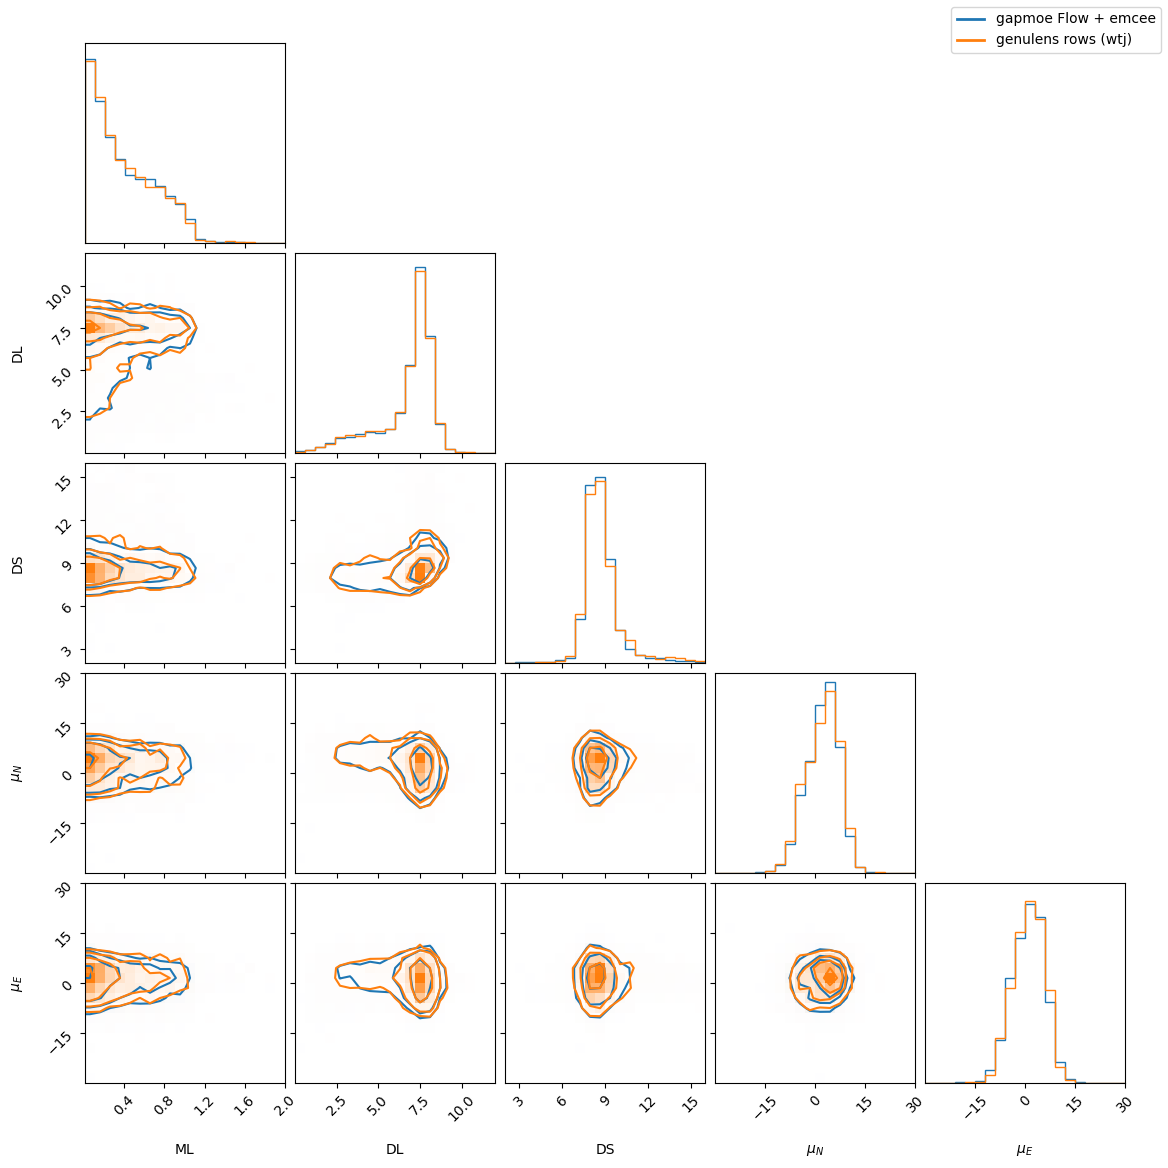

In [5]:
genulens_path = repo_root / "example" / "genulens_flow_out.dat"
rows = np.atleast_2d(np.genfromtxt(genulens_path, comments="#"))
weights = rows[:, 0]
pi_e = rows[:, 6]
mu_rel = rows[:, 9]
genulens_chain = np.column_stack((
    rows[:, 1],
    rows[:, 2] / 1000.0,
    rows[:, 3] / 1000.0,
    mu_rel * rows[:, 7] / pi_e,
    mu_rel * rows[:, 8] / pi_e,
))
valid = (
    np.isfinite(genulens_chain).all(axis=1)
    & np.isfinite(weights)
    & (weights > 0.0)
    & (pi_e > 0.0)
    & (genulens_chain[:, 0] > 0.0)
    & (genulens_chain[:, 1] > 0.0)
    & (genulens_chain[:, 2] > genulens_chain[:, 1])
)
genulens_chain, weights = genulens_chain[valid], weights[valid]

def weighted_quantile(values, sample_weights, probability=0.5):
    order = np.argsort(values)
    cumulative = np.cumsum(sample_weights[order])
    cumulative = cumulative / cumulative[-1]
    return np.interp(probability, cumulative, values[order])

print("weighted median comparison")
for index, label in enumerate(labels):
    flow_median = np.median(chain[:, index])
    genulens_median = weighted_quantile(genulens_chain[:, index], weights)
    print(f"{label:>7s}: Flow={flow_median:8.4f}  genulens={genulens_median:8.4f}")

plot_ranges = [(0.01, 2.0), (0.0, 12.0), (2.0, 16.0), (-30.0, 30.0), (-30.0, 30.0)]
fig = corner.corner(
    chain, labels=labels, range=plot_ranges, color="C0",
    plot_datapoints=False, hist_kwargs={"density": True},
)
corner.corner(
    genulens_chain, labels=labels, weights=weights, range=plot_ranges,
    fig=fig, color="tab:orange", plot_datapoints=False,
    fill_contours=False, hist_kwargs={"density": True},
)
fig.legend(handles=[
    Line2D([0], [0], color="C0", lw=2, label="gapmoe Flow + emcee"),
    Line2D([0], [0], color="tab:orange", lw=2, label="genulens rows (wtj)"),
], loc="upper right")
plt.show()

## 4. Integrate source brightness and color

A hard survey-style source selection is configured when the isochrone model is built. A measured source can then be supplied by band name to `log_density`, `sample`, `log_source_density`, and `source_radius`. CMD selection remains independent of the trained Galactic Flow.

In [6]:
selected_isochrone = model.isochrone(
    reference_band="Imag",
    color_bands=("Vmag", "Imag"),
    magnitude_range=(15.0, 21.0),
    color_range=(0.5, 3.0),
    reference_edges=reference_edges,
    color_edges=color_edges,
)
selected_prior = model.galactic_model(selected_isochrone)
source_magnitudes = {"Imag": 18.0, "Vmag": 20.0}

print(f"hard-selection log density = {float(selected_prior.log_density(theta)):.6f}")
print(f"brightness-conditioned log density = {float(selected_prior.log_density(theta, magnitudes=source_magnitudes)):.6f}")
print(f"log p(source photometry | DS=8 kpc) = {float(selected_prior.log_source_density(ds=8.0, magnitudes=source_magnitudes)):.6f}")
radius = selected_prior.source_radius(ds=8.0, magnitudes=source_magnitudes)
print(f"source radius = {float(radius.mean_rsun):.3f} +/- {float(radius.std_rsun):.3f} R_sun")

hard-selection log density = -9.032612


brightness-conditioned log density = -9.768522
log p(source photometry | DS=8 kpc) = -11.060999
source radius = 2.923 +/- 0.231 R_sun


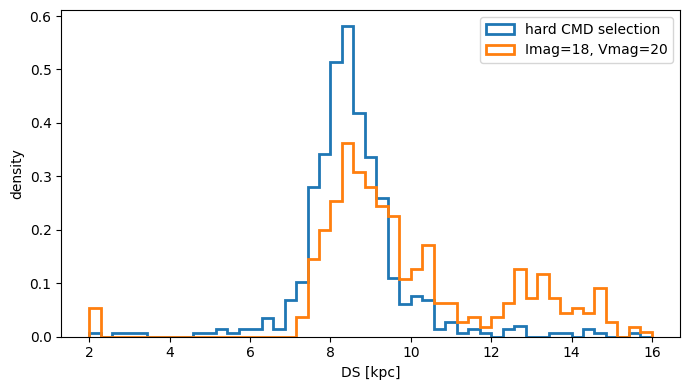

In [7]:
sample_keys = jax.random.split(jax.random.key(23), 512)
sample_selected = jax.jit(jax.vmap(lambda key: selected_prior.sample(key)))(sample_keys)
sample_brightness = jax.jit(jax.vmap(
    lambda key: selected_prior.sample(key, magnitudes=source_magnitudes)
))(sample_keys)
sample_selected = np.asarray(sample_selected)
sample_brightness = np.asarray(sample_brightness)

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(2.0, 16.0, 50)
ax.hist(sample_selected[:, 2], bins=bins, density=True, histtype="step", lw=2, label="hard CMD selection")
ax.hist(sample_brightness[:, 2], bins=bins, density=True, histtype="step", lw=2, label="Imag=18, Vmag=20")
ax.set(xlabel="DS [kpc]", ylabel="density")
ax.legend()
fig.tight_layout()
plt.show()